# リザバーの性質を測る — 短期記憶・非線形性・高次元性

`networks.modules` のリザバー (`Reservoir` / `BiReservoir` / `BiReservoir2D`) が、リザバー計算で標準的に使われる
3つの性質をどれだけ持っているかを測る。

| 性質 | 測定量 | 出典 |
|---|---|---|
| 短期記憶 | memory capacity $\mathrm{MC}_k$ | Jaeger (2001) |
| 非線形性 | information processing capacity の次数分解 | Dambre et al. (2012) |
| 高次元性 | participation ratio / kernel rank・generalization rank | Legenstein & Maass (2007) |

いずれも「リザバーの状態から線形読み出しで目標関数をどれだけ再構成できるか」という同じ枠組みで測れるので、
容量の計算を1つの関数にまとめ、目標関数を差し替えて使い回す。

最後に、このリポジトリ固有の `BiReservoir` / `BiReservoir2D` へ同じ測定を拡張する。

## 0. セットアップ

In [1]:
import os
import sys
import warnings

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
sys.path.append(os.path.abspath(".."))
warnings.filterwarnings("ignore")

import itertools

import matplotlib.pyplot as plt
import japanize_matplotlib
import torch

import networks

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__)
print("device:", DEVICE)

# 測定の共通設定
UNITS = 200  # リザバーのユニット数。容量の理論上限になる
T = 20_000  # 入力系列の長さ。容量の推定誤差は 1/sqrt(T - WASHOUT) 程度
WASHOUT = 500  # 初期状態の影響を捨てる区間
SEED = 0

# 容量は倍精度で計算する (状態の特異値が4桁ほど広がるため、単精度だと打ち切り誤差が乗る)
torch.manual_seed(SEED)

torch: 2.13.0+cu132
device: cuda


### 入力スケーリングについて

`Reservoir` は入力スケーリングを引数に持たず、`W_in` を Glorot 一様分布で固定している
（[modules.py:71-72](../networks/modules.py#L71-L72)）。`input_dim=1` だと `|W_in| <= sqrt(6/(1+units))`
なので、`units=200` では 0.17 程度にしかならず、$u \in [-1, 1]$ をそのまま入れると tanh はほぼ線形域で動く。

リザバーの動作点（線形寄りか非線形寄りか）を振るために、**信号側にスケールを掛けて** リザバーへ入れる。
`W_in` は固定なので、入力スケーリングを掛けるのと数学的に等価。目標関数は常にスケールなしの $u$ から作る
（容量は目標のスケールに対して不変なので、これで問題ない）。

In [2]:
input_signal = torch.rand(T, generator=torch.Generator().manual_seed(1)) * 2 - 1  # u(t) ~ U(-1, 1)

for scale in (0.5, 2.0, 8.0, 20.0):
    reservoir = networks.modules.Reservoir(1, UNITS, seed=SEED).to(DEVICE)
    with torch.no_grad():
        states = reservoir((input_signal * scale).reshape(1, -1, 1).to(DEVICE))
    print(
        f"input scale={scale:5.1f} -> |状態| の平均 {states.abs().mean():.3f}, "
        f"飽和率 (|h| > 0.9) {(states.abs() > 0.9).float().mean():.4f}"
    )

input scale=  0.5 -> |状態| の平均 0.032, 飽和率 (|h| > 0.9) 0.0000
input scale=  2.0 -> |状態| の平均 0.122, 飽和率 (|h| > 0.9) 0.0000
input scale=  8.0 -> |状態| の平均 0.347, 飽和率 (|h| > 0.9) 0.0038
input scale= 20.0 -> |状態| の平均 0.539, 飽和率 (|h| > 0.9) 0.0951


## 1. 共通ユーティリティ: 容量の計算

状態行列 $X \in \mathbb{R}^{S \times N}$（列平均を引いたもの）の張る部分空間の正規直交基底を $Q$ とすると、
目標 $z$ に対する容量は

$$ C[z] = \frac{\lVert Q^{\top} z \rVert^2}{\lVert z \rVert^2} \in [0, 1] $$

で、これはリッジ回帰ではなく最小二乗の決定係数 $R^2$ そのもの。目標をまとめて行列にすれば1回の行列積で全部求まる。

**有意水準**: 標本数が有限なので、$u$ と全く無関係な目標でも容量は 0 にならず $\approx \mathrm{rank}(X)/S$ 程度の値が出る。
そこで $u$ と独立な乱数目標（surrogate）の容量分布を作り、その上側分位点を下回った容量は 0 に落とす。
この処理を入れないと、遅れの大きい項や高次の項の「ゴミ」を足し上げてしまい、総容量が大きく過大評価される。

In [3]:
def run_reservoir(reservoir, signal, washout=WASHOUT):
    """1次元信号をリザバーに流し、washout 後の状態を返す。 (T,) -> (T - washout, units)"""
    with torch.no_grad():
        states = reservoir(signal.reshape(1, -1, 1).to(DEVICE))

    return states[0, washout:].double()


def make_surrogates(n_samples, n_surrogate=300, seed=7):
    """入力と独立な乱数目標。有意水準の推定に使う。"""
    g = torch.Generator().manual_seed(seed)

    return (torch.rand(n_samples, n_surrogate, generator=g) * 2 - 1).double().to(DEVICE)


def capacity(states, targets, surrogates=None, rtol=1e-8, quantile=0.999):
    """各目標に対する容量を返す。

    Returns:
        capacities: (目標数,) 有意水準以下を 0 にした容量
        threshold: 有意水準
        rank: 状態行列の数値的ランク (容量の総和はこれを超えられない)
    """
    X = states - states.mean(0, keepdim=True)
    Z = targets - targets.mean(0, keepdim=True)

    U_, S_, _ = torch.linalg.svd(X, full_matrices=False)
    Q = U_[:, S_ > rtol * S_[0]]

    def project(Y):
        return ((Q.T @ Y).pow(2).sum(0) / Y.pow(2).sum(0)).clamp(0, 1)

    threshold = 0.0
    if surrogates is not None:
        threshold = project(surrogates - surrogates.mean(0, keepdim=True)).quantile(quantile).item()

    caps = project(Z)

    return torch.where(caps > threshold, caps, torch.zeros_like(caps)).cpu(), threshold, int(Q.shape[1])


SURROGATES = make_surrogates(T - WASHOUT)
print(f"標本数 S = {T - WASHOUT}, surrogate の数 = {SURROGATES.shape[1]}")

標本数 S = 19500, surrogate の数 = 300


## 2. 短期記憶 (memory capacity)

$\mathrm{MC}_k$ は $k$ ステップ前の入力 $u(t-k)$ を状態から再構成できる割合。総和 $\mathrm{MC} = \sum_k \mathrm{MC}_k$ は
ユニット数 $N$ を超えられない（線形読み出しの自由度が $N$ しかないため）。

有意水準 0.0146   状態のランク 200 / 200
MC 合計 = 20.54   (上限 N = 200)
MC_k = k=1:1.000  k=2:1.000  k=5:1.000  k=10:0.992  k=20:0.453  k=40:0.031  k=80:0.000


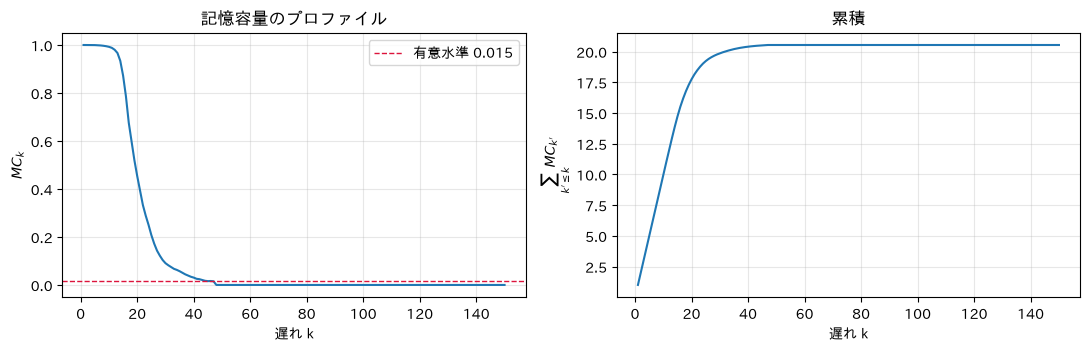

In [4]:
def memory_capacity(reservoir, scale, max_delay=150, signal=input_signal):
    states = run_reservoir(reservoir, signal * scale)
    targets = torch.stack([signal[WASHOUT - k : T - k] for k in range(1, max_delay + 1)], dim=1)

    return capacity(states, targets.double().to(DEVICE), SURROGATES)


INPUT_SCALE = 2.0  # 以降の既定の動作点

reservoir = networks.modules.Reservoir(1, UNITS, seed=SEED).to(DEVICE)
mc, thr, rank = memory_capacity(reservoir, INPUT_SCALE)

print(f"有意水準 {thr:.4f}   状態のランク {rank} / {UNITS}")
print(f"MC 合計 = {mc.sum():.2f}   (上限 N = {UNITS})")
print("MC_k = " + "  ".join(f"k={k}:{mc[k - 1]:.3f}" for k in (1, 2, 5, 10, 20, 40, 80)))

plt.figure(figsize=(11, 3.6))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(mc) + 1), mc, lw=1.5)
plt.axhline(thr, color="crimson", ls="--", lw=1, label=f"有意水準 {thr:.3f}")
plt.xlabel("遅れ k")
plt.ylabel("$MC_k$")
plt.title("記憶容量のプロファイル")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(mc) + 1), torch.cumsum(mc, 0), lw=1.5)
plt.xlabel("遅れ k")
plt.ylabel("$\\sum_{k'\\leq k} MC_{k'}$")
plt.title("累積")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2.1 ハイパーパラメータ依存性

`src/classification.py` が Optuna で振っているのと同じパラメータ（`spectral_radius` / `leaky` / `units` /
`connectivity`）に対して MC がどう動くかを見る。

[spectral_radius]
  spectral_radius=   0.3  MC= 10.66  rank=200
  spectral_radius=   0.6  MC= 14.11  rank=200
  spectral_radius=   0.8  MC= 17.13  rank=200
  spectral_radius=  0.95  MC= 20.54  rank=200
  spectral_radius=   1.1  MC= 19.22  rank=200
  spectral_radius=   1.3  MC= 18.38  rank=200
[leaky]
  leaky=   0.2  MC= 15.08  rank=200
  leaky=   0.4  MC= 17.08  rank=200
  leaky=   0.6  MC= 17.59  rank=200
  leaky=   0.8  MC= 19.17  rank=200
  leaky=   1.0  MC= 22.77  rank=200
[connectivity]
  connectivity=  0.02  MC= 21.08  rank=199
  connectivity=  0.05  MC= 21.63  rank=200
  connectivity=   0.1  MC= 20.54  rank=200
  connectivity=   0.3  MC= 21.83  rank=200
  connectivity=   0.9  MC= 23.99  rank=200
[units]
  units=    50  MC= 11.41  rank=50
  units=   100  MC= 16.15  rank=100
  units=   200  MC= 20.54  rank=200
  units=   400  MC= 31.09  rank=400


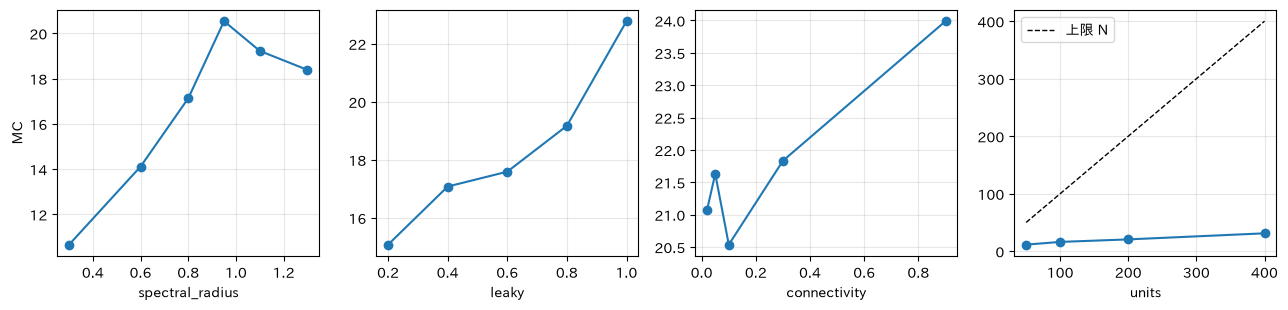

In [5]:
def sweep(param, values, **fixed):
    rows = []
    for v in values:
        kwargs = dict(connectivity=0.1, leaky=0.9, spectral_radius=0.95, units=UNITS, **fixed)
        kwargs[param] = v
        res = networks.modules.Reservoir(1, kwargs.pop("units"), seed=SEED, **kwargs).to(DEVICE)
        mc_, thr_, rank_ = memory_capacity(res, INPUT_SCALE)
        rows.append((v, mc_.sum().item(), rank_))
        print(f"  {param}={v!s:>6}  MC={rows[-1][1]:6.2f}  rank={rank_}")
    return rows


sweeps = {}
for param, values in (
    ("spectral_radius", [0.3, 0.6, 0.8, 0.95, 1.1, 1.3]),
    ("leaky", [0.2, 0.4, 0.6, 0.8, 1.0]),
    ("connectivity", [0.02, 0.05, 0.1, 0.3, 0.9]),
    ("units", [50, 100, 200, 400]),
):
    print(f"[{param}]")
    sweeps[param] = sweep(param, values)

plt.figure(figsize=(13, 3.2))
for i, (param, rows) in enumerate(sweeps.items()):
    plt.subplot(1, 4, i + 1)
    plt.plot([r[0] for r in rows], [r[1] for r in rows], "o-")
    if param == "units":
        plt.plot([r[0] for r in rows], [r[0] for r in rows], "k--", lw=1, label="上限 N")
        plt.legend()
    plt.xlabel(param)
    plt.ylabel("MC" if i == 0 else "")
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2.2 なぜ忘れるのか — 摂動の伝播

ある1時刻だけ入力を変えた2本の系列を流し、状態の距離がどう減衰するかを見る。
距離が 0 に収束することはエコー状態性（初期状態を忘れること）の確認でもある。

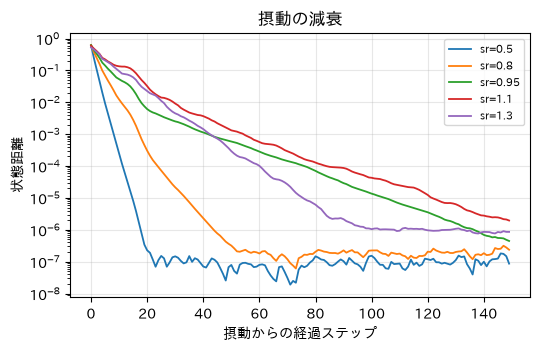

In [6]:
base = (torch.rand(1, 400, 1, generator=torch.Generator().manual_seed(9)) * 2 - 1) * INPUT_SCALE
perturbed = base.clone()
perturbed[0, 100, 0] += 0.5

plt.figure(figsize=(5.5, 3.6))
for sr in (0.5, 0.8, 0.95, 1.1, 1.3):
    res = networks.modules.Reservoir(1, UNITS, spectral_radius=sr, seed=SEED).to(DEVICE)
    with torch.no_grad():
        dist = (res(base.to(DEVICE))[0] - res(perturbed.to(DEVICE))[0]).norm(dim=-1)
    plt.semilogy(dist[100:250].cpu(), lw=1.3, label=f"sr={sr}")

plt.xlabel("摂動からの経過ステップ")
plt.ylabel("状態距離")
plt.legend(fontsize=8)
plt.title("摂動の減衰")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. 非線形性 (information processing capacity)

Dambre et al. (2012) の枠組み。入力が i.i.d. 一様分布なら、遅れた入力の**正規化 Legendre 多項式の積**が
$L^2$ の正規直交基底になる。基底関数それぞれの容量を測り、次数ごとに足し上げれば

- 次数 1 の合計 = 線形な情報処理容量（= memory capacity）
- 次数 2 以上の合計 = 非線形な情報処理容量

と分解できる。総和は状態のランク $N$ を超えない。

In [7]:
def legendre(x, n):
    """[-1, 1] 上の Legendre 多項式 (正規化係数は容量に影響しないので省略)。"""
    return {1: x, 2: (3 * x**2 - 1) / 2, 3: (5 * x**3 - 3 * x) / 2}[n]


# (遅れ, 次数) の組で基底を列挙する。次数が上がるほど組み合わせが増えるので遅れの窓を狭める
BASIS_FAMILIES = {
    "次数1: $P_1(u_{t-d})$": [((d, 1),) for d in range(0, 150)],
    "次数2: $P_2(u_{t-d})$": [((d, 2),) for d in range(0, 25)],
    "次数2: $P_1 P_1$": [((a, 1), (b, 1)) for a, b in itertools.combinations(range(0, 25), 2)],
    "次数3: $P_3(u_{t-d})$": [((d, 3),) for d in range(0, 12)],
    "次数3: $P_2 P_1$": [((a, 2), (b, 1)) for a, b in itertools.permutations(range(0, 12), 2)],
    "次数3: $P_1 P_1 P_1$": [((a, 1), (b, 1), (c, 1)) for a, b, c in itertools.combinations(range(0, 12), 3)],
}
BASIS = [spec for family in BASIS_FAMILIES.values() for spec in family]
DEGREES = torch.tensor([sum(n for _, n in spec) for spec in BASIS])


def build_basis_targets(signal=input_signal):
    def delayed(d):
        return signal[WASHOUT - d : T - d].double().to(DEVICE)

    return torch.stack([torch.stack([legendre(delayed(d), n) for d, n in spec]).prod(0) for spec in BASIS], dim=1)


IPC_TARGETS = build_basis_targets()
print(f"基底の数: {len(BASIS)}  " + "  ".join(f"次数{d}: {(DEGREES == d).sum()}" for d in (1, 2, 3)))

# 基底の直交性チェック (有限標本なので非対角は 0 ではなく ~1/sqrt(S) に収まっていればよい)
Zn = IPC_TARGETS - IPC_TARGETS.mean(0, keepdim=True)
Zn = Zn / Zn.norm(dim=0, keepdim=True)
gram = (Zn.T @ Zn - torch.eye(len(BASIS), device=DEVICE, dtype=Zn.dtype)).abs()
print(f"Gram 行列 非対角の最大値: {gram.max():.4f}  (目安 1/sqrt(S) = {(T - WASHOUT) ** -0.5:.4f})")

[W814 08:58:49.559380250 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 2097152 bytes (free: 2752512, total: 50896568320).


基底の数: 839  次数1: 150  次数2: 325  次数3: 364
Gram 行列 非対角の最大値: 0.0374  (目安 1/sqrt(S) = 0.0072)


### 3.1 対照実験: 厳密に線形なリザバーで測定コードを検証する

測定が正しければ、tanh を外した線形リザバーでは **次数2以上の容量がちょうど 0** になるはずである。
これは容量計算と基底の構成に対する強い検証になる（この確認を通らない実装は、非線形容量を幻視する）。

In [8]:
def linear_reference_states(signal, units=UNITS, seed=SEED, leaky=0.9):
    """networks.modules.Reservoir から tanh だけを取り除いた参照実装 (検証専用)。"""
    g = torch.Generator().manual_seed(seed)
    W_in = ((torch.rand(1, units, generator=g) * 2 - 1) * (6.0 / (1 + units)) ** 0.5).double().to(DEVICE)
    W_rec = (torch.rand(units, units, generator=g) * 2 - 1) * (6.0 / (2 * units)) ** 0.5
    W_rec = (W_rec * (torch.rand(units, units, generator=g) < 0.1).float()).double().to(DEVICE)
    W_rec = W_rec * (0.95 / torch.linalg.eigvals(W_rec).abs().max().real)

    xW = signal.reshape(-1, 1).double().to(DEVICE) @ W_in
    h = torch.zeros(1, units, dtype=torch.float64, device=DEVICE)
    out = torch.empty(len(signal), units, dtype=torch.float64, device=DEVICE)
    for t in range(len(signal)):
        h = torch.lerp(h, xW[t] + h @ W_rec, leaky)  # tanh なし
        out[t] = h

    return out[WASHOUT:]


def capacity_by_family(states):
    caps, thr, rank = capacity(states, IPC_TARGETS, SURROGATES)
    i, by_family = 0, {}
    for name, family in BASIS_FAMILIES.items():
        by_family[name] = caps[i : i + len(family)].sum().item()
        i += len(family)

    return caps, by_family, thr, rank


caps_lin, fam_lin, _, rank_lin = capacity_by_family(linear_reference_states(input_signal * INPUT_SCALE))
print(f"線形リザバー: 総容量 {caps_lin.sum():.2f} / rank {rank_lin}")
for name, value in fam_lin.items():
    print(f"  {name:26s} {value:8.3f}")

assert caps_lin[DEGREES >= 2].sum() < 1e-6, "線形リザバーで非線形容量が検出された = 測定側のバグ"
print("\n次数2以上の容量が 0 であることを確認 -> 容量計算と基底は正しい")

線形リザバー: 総容量 53.98 / rank 54
  次数1: $P_1(u_{t-d})$          53.975
  次数2: $P_2(u_{t-d})$           0.000
  次数2: $P_1 P_1$                0.000
  次数3: $P_3(u_{t-d})$           0.000
  次数3: $P_2 P_1$                0.000
  次数3: $P_1 P_1 P_1$            0.000

次数2以上の容量が 0 であることを確認 -> 容量計算と基底は正しい


### 3.2 tanh リザバーの次数分解と、記憶 – 非線形性のトレードオフ

入力スケールを上げると tanh の動作点が非線形域に入る。線形容量（= MC）が減り、非線形容量に移っていく。

**打ち切りについての注意**: 総容量は必ず $\mathrm{rank}(X)$ に等しくなる（Dambre らの容量保存則）が、
ここでは次数 3 まで・限られた遅れ幅までしか基底を張っていない。したがって
**「捕捉率 = 総容量 / rank」が下がること自体が、容量がより高次の項へ移った証拠**になる。

scale=  0.5  線形  30.71  非線形 138.27  総 168.99 / rank 200  (捕捉率 84.5%)
scale=  1.0  線形  26.37  非線形 141.56  総 167.93 / rank 200  (捕捉率 84.0%)
scale=  2.0  線形  21.54  非線形 142.83  総 164.36 / rank 200  (捕捉率 82.2%)
scale=  4.0  線形  16.29  非線形 124.66  総 140.96 / rank 200  (捕捉率 70.5%)
scale=  8.0  線形  11.36  非線形  81.64  総  93.00 / rank 200  (捕捉率 46.5%)
scale= 16.0  線形   7.59  非線形  42.73  総  50.31 / rank 200  (捕捉率 25.2%)


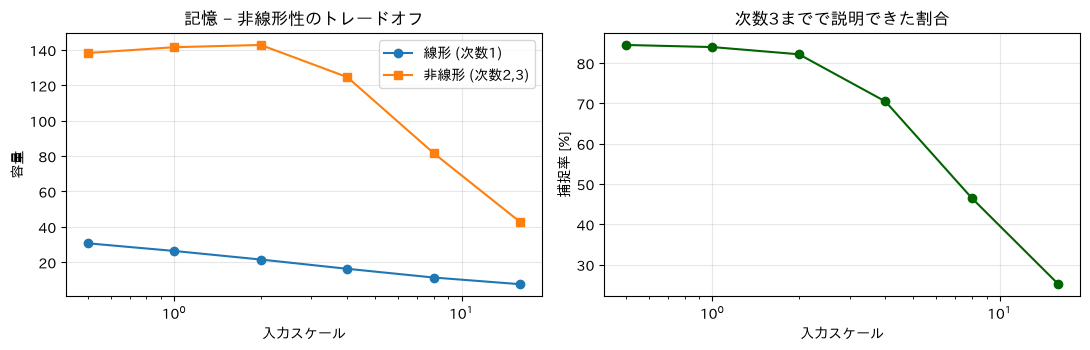

In [9]:
scales = [0.5, 1.0, 2.0, 4.0, 8.0, 16.0]
ipc_rows = []

for scale in scales:
    res = networks.modules.Reservoir(1, UNITS, seed=SEED).to(DEVICE)
    caps_, fam_, thr_, rank_ = capacity_by_family(run_reservoir(res, input_signal * scale))
    lin = caps_[DEGREES == 1].sum().item()
    non = caps_[DEGREES >= 2].sum().item()
    ipc_rows.append((scale, lin, non, caps_.sum().item(), rank_))
    print(
        f"scale={scale:5.1f}  線形 {lin:6.2f}  非線形 {non:6.2f}  "
        f"総 {caps_.sum():6.2f} / rank {rank_}  (捕捉率 {caps_.sum() / rank_ * 100:4.1f}%)"
    )

plt.figure(figsize=(11, 3.6))
plt.subplot(1, 2, 1)
plt.plot(scales, [r[1] for r in ipc_rows], "o-", label="線形 (次数1)")
plt.plot(scales, [r[2] for r in ipc_rows], "s-", label="非線形 (次数2,3)")
plt.xscale("log")
plt.xlabel("入力スケール")
plt.ylabel("容量")
plt.legend()
plt.title("記憶 – 非線形性のトレードオフ")
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(scales, [r[3] / r[4] * 100 for r in ipc_rows], "o-", color="darkgreen")
plt.xscale("log")
plt.xlabel("入力スケール")
plt.ylabel("捕捉率 [%]")
plt.title("次数3までで説明できた割合")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

tanh リザバー (scale=2.0): 総容量 164.36 / rank 200
  次数1: $P_1(u_{t-d})$          21.536
  次数2: $P_2(u_{t-d})$           0.000
  次数2: $P_1 P_1$                0.137
  次数3: $P_3(u_{t-d})$           5.046
  次数3: $P_2 P_1$               52.476
  次数3: $P_1 P_1 P_1$           85.169


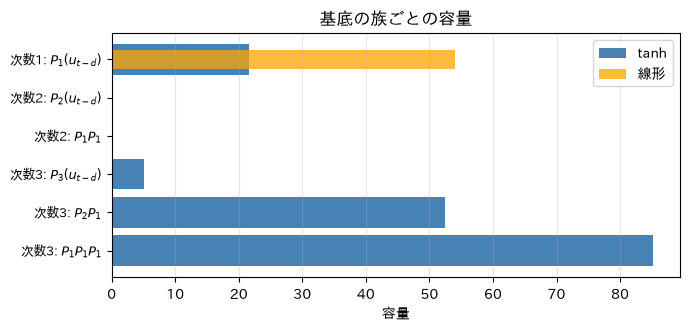

In [10]:
# 既定の動作点での内訳
res = networks.modules.Reservoir(1, UNITS, seed=SEED).to(DEVICE)
caps_tanh, fam_tanh, thr_tanh, rank_tanh = capacity_by_family(run_reservoir(res, input_signal * INPUT_SCALE))
print(f"tanh リザバー (scale={INPUT_SCALE}): 総容量 {caps_tanh.sum():.2f} / rank {rank_tanh}")
for name, value in fam_tanh.items():
    print(f"  {name:26s} {value:8.3f}")

plt.figure(figsize=(7, 3.4))
names = list(fam_tanh)
plt.barh(range(len(names)), [fam_tanh[n] for n in names], color="steelblue", label="tanh")
plt.barh(range(len(names)), [fam_lin[n] for n in names], color="orange", alpha=0.75, height=0.5, label="線形")
plt.yticks(range(len(names)), names, fontsize=9)
plt.xlabel("容量")
plt.legend()
plt.title("基底の族ごとの容量")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

偶数次数（$P_2$、$P_1P_1$）の容量がほぼ 0 になるのは、tanh が奇関数で、リザバーの写像が
$u \mapsto -u$ に対して $h \mapsto -h$ の対称性を持つため。偶関数な目標はこの対称性のせいで
状態と無相関になる。バイアス項を持たないリザバーの構造から来る性質で、実装の不具合ではない。

## 4. 高次元性

「入力を高次元空間へ写して線形分離しやすくする」というリザバーの役割を2つの角度から測る。

- **participation ratio**: 状態共分散の固有値 $\lambda_i$ に対し $\mathrm{PR} = (\sum \lambda_i)^2 / \sum \lambda_i^2$。
  分散がどれだけ多くの方向に散っているか（実際に使われている次元数）。
- **kernel rank / generalization rank**: 互いに独立な入力を与えたときの状態行列のランク（分離能力）と、
  同じクラスの入力を与えたときのランク（汎化能力）。前者が高く後者が低いほど良い。

participation ratio = 3.5 / 200
数値的ランク (容量の上限) = 200 / 200


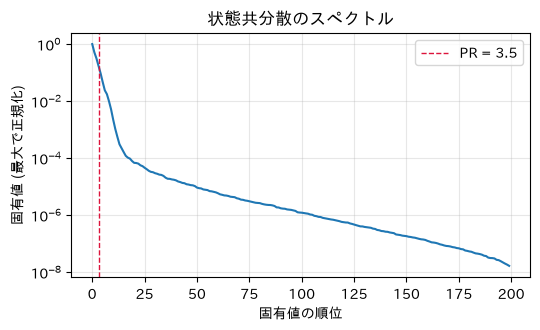

In [11]:
res = networks.modules.Reservoir(1, UNITS, seed=SEED).to(DEVICE)
states = run_reservoir(res, input_signal * INPUT_SCALE)
eigvals = torch.linalg.eigvalsh(torch.cov(states.T)).clamp_min(0).flip(0)
pr = (eigvals.sum() ** 2 / eigvals.pow(2).sum()).item()

print(f"participation ratio = {pr:.1f} / {UNITS}")
print(f"数値的ランク (容量の上限) = {capacity(states, IPC_TARGETS[:, :1])[2]} / {UNITS}")

plt.figure(figsize=(5.5, 3.4))
plt.semilogy((eigvals / eigvals[0]).cpu(), lw=1.5)
plt.axvline(pr, color="crimson", ls="--", lw=1, label=f"PR = {pr:.1f}")
plt.xlabel("固有値の順位")
plt.ylabel("固有値 (最大で正規化)")
plt.legend()
plt.title("状態共分散のスペクトル")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

ランク（= 容量の上限）は満杯なのに participation ratio は小さい。
つまり**線形読み出しから見れば全次元が使えるが、分散のほとんどはごく少数の方向に乗っている**という状態。
2つは別のことを測っているので、どちらか一方だけを「次元数」と呼ばないほうがよい。

In [12]:
def kernel_ranks(reservoir, n_stream=300, length=60, n_template=30, noise=0.05, rtols=(1e-1, 1e-2, 1e-3, 1e-4)):
    g = lambda s: torch.Generator().manual_seed(s)

    # 分離能力: 互いに独立な入力
    independent = (torch.rand(n_stream, length, 1, generator=g(2)) * 2 - 1) * INPUT_SCALE

    # 汎化能力: n_template 個の原型に微小ノイズを載せたもの (= 同じクラスの入力)
    template = (torch.rand(n_template, length, 1, generator=g(3)) * 2 - 1).repeat_interleave(n_stream // n_template, 0)
    same_class = ((template + noise * torch.randn(template.shape, generator=g(4))).clamp(-1, 1)) * INPUT_SCALE

    out = {}
    with torch.no_grad():
        for name, x in (("kernel rank", independent), ("generalization rank", same_class)):
            final = reservoir(x.to(DEVICE))[:, -1].double()
            final = final - final.mean(0, keepdim=True)
            out[name] = [torch.linalg.matrix_rank(final, rtol=r).item() for r in rtols]

    return out, rtols


ranks, rtols = kernel_ranks(networks.modules.Reservoir(1, UNITS, seed=SEED).to(DEVICE))
print("打ち切り閾値 rtol:      " + "".join(f"{r:9.0e}" for r in rtols))
for name, values in ranks.items():
    print(f"{name:22s}" + "".join(f"{v:9d}" for v in values))
print(f"\n原型の数 = 30 なので、generalization rank がこれに近ければ")
print("同じクラスの入力を同じ状態へ潰せている (= 汎化している) と読める。")
print("ランクは打ち切り閾値に強く依存するので、絶対値ではなく2つの差を見ること。")

打ち切り閾値 rtol:          1e-01    1e-02    1e-03    1e-04
kernel rank                   8       17       94      186
generalization rank           7       16       36      110

原型の数 = 30 なので、generalization rank がこれに近ければ
同じクラスの入力を同じ状態へ潰せている (= 汎化している) と読める。
ランクは打ち切り閾値に強く依存するので、絶対値ではなく2つの差を見ること。


## 5. 双方向・2次元への拡張

ここからはこのリポジトリ固有の構造。`BiReservoir` は系列を順逆両方向から走査し、`BiReservoir2D` は行方向と列方向の
`BiReservoir` を並べる。「短期記憶」は時間的な片側の記憶を測る量なので、そのままでは当てはまらない。
代わりに **どの位置の入力を再構成できるか**（文脈容量）を測る。

### 5.1 BiReservoir: 両側に伸びる文脈

`BiReservoir` の位置 $t$ の状態から $u(t + k)$ を再構成できる割合を、$k$ の正負両方について測る。
単方向の `Reservoir` と重ねると違いが分かる。

In [13]:
MARGIN, MAX_OFFSET = 300, 80
signal_ctx = input_signal * INPUT_SCALE
offsets = list(range(-MAX_OFFSET, MAX_OFFSET + 1))
targets_ctx = torch.stack([input_signal[MARGIN + k : T - MARGIN + k] for k in offsets], dim=1).double().to(DEVICE)
surrogates_ctx = make_surrogates(T - 2 * MARGIN)

context = {}
for name, model in (
    ("Reservoir (単方向)", networks.modules.Reservoir(1, UNITS, seed=SEED).to(DEVICE)),
    ("BiReservoir (双方向)", networks.modules.BiReservoir(1, UNITS, seed=SEED).to(DEVICE)),
):
    with torch.no_grad():
        st = model(signal_ctx.reshape(1, -1, 1).to(DEVICE))[0, MARGIN : T - MARGIN].double()
    caps_, thr_, rank_ = capacity(st, targets_ctx, surrogates_ctx)
    context[name] = caps_
    print(
        f"{name:20s} 総容量 {caps_.sum():6.2f}  (k<0 側 {caps_[:MAX_OFFSET].sum():5.2f} / "
        f"k>0 側 {caps_[MAX_OFFSET + 1 :].sum():5.2f})  rank={rank_}"
    )

plt.figure(figsize=(6, 3.6))
for name, caps_ in context.items():
    plt.plot(offsets, caps_, lw=1.4, label=name)
plt.axvline(0, color="k", lw=0.8)
plt.xlabel("オフセット k  (負 = 過去, 正 = 未来)")
plt.ylabel("容量")
plt.title("$u(t+k)$ を再構成できる割合")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

[W814 08:59:04.683941060 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 404750336 bytes (free: 61472768, total: 50896568320).
[W814 08:59:04.690514804 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 404750336 bytes (free: 214564864, total: 50896568320).


OutOfMemoryError: CUDA out of memory. Tried to allocate 386.00 MiB. GPU 0 has a total capacity of 47.40 GiB of which 204.62 MiB is free. Process 780034 has 45.91 GiB memory in use. Including non-PyTorch memory, this process has 1.26 GiB memory in use. Of the allocated memory 548.85 MiB is allocated by PyTorch, and 409.15 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

### 5.2 BiReservoir2D: 受容野は十字になる

`BiReservoir2D` は位置 $(i, j)$ の出力を「行 $i$ を走査した水平リザバー」と「列 $j$ を走査した垂直リザバー」の
連結で作る（[modules.py:163-175](../networks/modules.py#L163-L175)）。したがって1層では
**同じ行か同じ列の入力しか見ていない**はずである。オフセット $(dy, dx)$ ごとの容量マップで確かめる。

1 層: 十字上の容量  12.97 / 十字外   0.00  (有意水準 0.028, rank 200)
2 層: 十字上の容量  12.82 / 十字外  27.70  (有意水準 0.027, rank 200)
3 層: 十字上の容量  12.57 / 十字外  27.15  (有意水準 0.028, rank 200)


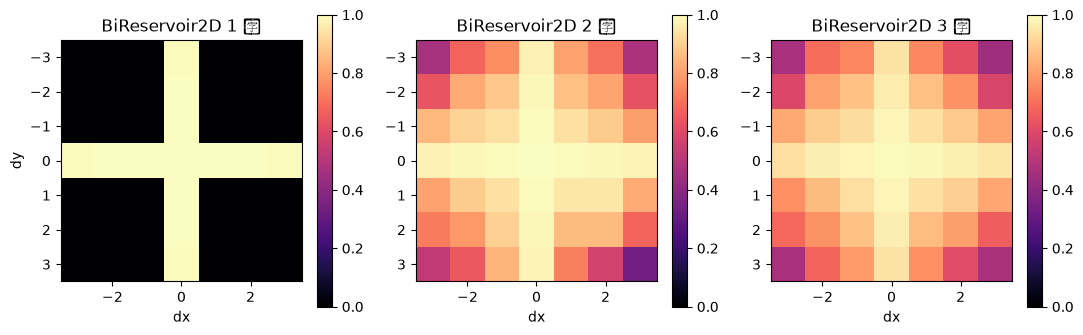

In [ ]:
GRID, N_IMAGE, MARGIN2D, MAX_OFF2D = 24, 64, 6, 3

image = (torch.rand(N_IMAGE, GRID, GRID, 1, generator=torch.Generator().manual_seed(5)) * 2 - 1).to(DEVICE)
inner = slice(MARGIN2D, GRID - MARGIN2D)
n_inner = GRID - 2 * MARGIN2D
surrogates_2d = make_surrogates(N_IMAGE * n_inner**2, seed=6)

offsets_2d = [(dy, dx) for dy in range(-MAX_OFF2D, MAX_OFF2D + 1) for dx in range(-MAX_OFF2D, MAX_OFF2D + 1)]
targets_2d = torch.stack(
    [
        image[:, MARGIN2D + dy : GRID - MARGIN2D + dy, MARGIN2D + dx : GRID - MARGIN2D + dx, 0].reshape(-1)
        for dy, dx in offsets_2d
    ],
    dim=1,
).double()


def capacity_map(n_layer):
    x, dim, layers = image * INPUT_SCALE, 1, []
    for k in range(n_layer):
        layers.append(networks.modules.BiReservoir2D(dim, UNITS, seed=10 * k).to(DEVICE))
        dim = UNITS
    with torch.no_grad():
        for layer in layers:
            x = layer(x)

    caps_, thr_, rank_ = capacity(x[:, inner, inner, :].reshape(-1, UNITS).double(), targets_2d, surrogates_2d)
    side = 2 * MAX_OFF2D + 1

    return caps_.reshape(side, side), thr_, rank_


# 同じ行 (dy=0) か同じ列 (dx=0) にあたる位置のマスク
CROSS = torch.zeros(2 * MAX_OFF2D + 1, 2 * MAX_OFF2D + 1, dtype=torch.bool)
CROSS[MAX_OFF2D, :] = True
CROSS[:, MAX_OFF2D] = True

maps = {}
for n_layer in (1, 2, 3):
    m, thr_, rank_ = capacity_map(n_layer)
    maps[n_layer] = m
    print(
        f"{n_layer} 層: 十字上の容量 {m[CROSS].sum():6.2f} / 十字外 {m[~CROSS].sum():6.2f}  "
        f"(有意水準 {thr_:.3f}, rank {rank_})"
    )

plt.figure(figsize=(11, 3.4))
for i, (n_layer, m) in enumerate(maps.items()):
    plt.subplot(1, 3, i + 1)
    plt.imshow(
        m, vmin=0, vmax=1, cmap="magma", extent=[-MAX_OFF2D - 0.5, MAX_OFF2D + 0.5, MAX_OFF2D + 0.5, -MAX_OFF2D - 0.5]
    )
    plt.colorbar()
    plt.xlabel("dx")
    plt.ylabel("dy" if i == 0 else "")
    plt.title(f"BiReservoir2D {n_layer} 層")
plt.tight_layout()
plt.show()

1層の `BiReservoir2D` の受容野は厳密に十字（同じ行・同じ列のみ）で、斜め方向の容量はちょうど 0 になる。
層を重ねると、前段の出力がすでに行方向の情報を含んでいるため、次段の列走査がそれを混ぜて十字が埋まる。

`birc2d_base_v1` が各枝で `BiReservoir2D` を `N=10` 段重ね（[birc2d_base_v1.py:52-56](../networks/extractors/birc2d_base_v1.py#L52-L56)）、
`birc2d_base_v2` がブロックを積んでいるのは、この十字を埋めて2次元の受容野を作るためと読める。
**1層だけで使うと画像の斜め方向の相関を一切捉えられない**ので、層数は精度に直結するパラメータになる。

### 5.3 レイヤごとの受容野を比べる

5.2 の測り方はレイヤの中身に依存しないので、`networks.modules` の2次元レイヤなら何でも同じ土俵に載る。
ここでは `BiReservoir2D` と `ReservoirConv2D` を並べる。2つは受容野の作り方が正反対で、

- `BiReservoir2D`: 行・列を**丸ごと**走査する（[modules.py:158-170](../networks/modules.py#L158-L170)）。
  受容野は十字に限られる代わりに、その方向には距離の制限がない
- `ReservoirConv2D`: 各位置で $K \times K$ の ROI を切り出し、**その中だけ**を走査して最終状態を取る
  （[modules.py:299-311](../networks/modules.py#L299-L311)）。斜めも埋まっている代わりに、受容野は $K \times K$ に厳密に限られる

という違いがある。出力次元を 200 に揃えて比較する。

**2つの測り方を併用する**:

| 測定 | 何を見るか | 限界 |
|---|---|---|
| 容量マップ | 線形読み出しで**復元できる**割合 | 情報が届いていても非線形にしか残っていなければ 0 になる |
| 感度マップ | 中心画素を摂動したときの出力の動き | 値の大きさは動作点依存。ただし受容野の**台**（届く / 届かない）は厳密 |

容量マップだけだと「0 は届いていないからなのか、読み出せないだけなのか」が区別できない。
感度マップは1画素の摂動が出力マップのどこへ届くか（投射野）を**1回の摂動で全オフセット同時に**測り、
点対称に反転して受容野の向きへ揃える。2つ合わせて「届くか」と「読み出せるか」の両方が言える。

In [ ]:
# 5.2 より窓を広げ (+-8)、標本数も増やして有意水準を下げる
RF_GRID, RF_IMAGES, RF_MARGIN, RF_OFF, RF_CHUNK = 32, 128, 10, 8, 16
RF_SIDE = 2 * RF_OFF + 1
_rf_inner = RF_GRID - 2 * RF_MARGIN

rf_image = (torch.rand(RF_IMAGES, RF_GRID, RF_GRID, 1, generator=torch.Generator().manual_seed(5)) * 2 - 1).to(DEVICE)
rf_offsets = [(dy, dx) for dy in range(-RF_OFF, RF_OFF + 1) for dx in range(-RF_OFF, RF_OFF + 1)]
rf_surrogates = make_surrogates(RF_IMAGES * _rf_inner**2, seed=6)
rf_targets = torch.stack(
    [
        rf_image[:, RF_MARGIN + dy : RF_GRID - RF_MARGIN + dy, RF_MARGIN + dx : RF_GRID - RF_MARGIN + dx, 0].reshape(-1)
        for dy, dx in rf_offsets
    ],
    dim=1,
).double()

# 同じ行 (dy=0) か同じ列 (dx=0) にあたる位置のマスク
RF_CROSS = torch.zeros(RF_SIDE, RF_SIDE, dtype=torch.bool)
RF_CROSS[RF_OFF, :] = True
RF_CROSS[:, RF_OFF] = True


@torch.no_grad()
def rf_forward(layers, x, take=None):
    """ReservoirConv2D の ROI 展開が (B, H, W, C, K, K) と大きいのでチャンクに分ける。

    take: 出力チャネルの一部だけを使う場合のスライス (BiReservoir2D の水平枝 / 垂直枝の切り分けに使う)。
    """
    out = []
    for i in range(0, len(x), RF_CHUNK):
        y = layers(x[i : i + RF_CHUNK])
        out.append(y if take is None else y[..., take])

    return torch.cat(out)


def capacity_field(layers, take=None):
    """線形読み出しで復元できる割合のマップ。5.2 と同じ量。"""
    out = rf_forward(layers, rf_image * INPUT_SCALE, take)
    if out.shape[1] != RF_GRID:
        raise ValueError("stride 1 のレイヤのみ対応 (プーリングを挟む場合は目標側も同じ倍率で間引く必要がある)")

    inner = slice(RF_MARGIN, RF_GRID - RF_MARGIN)
    states = out[:, inner, inner, :].reshape(-1, out.shape[-1]).double()

    caps_, thr_, rank_ = capacity(states, rf_targets, rf_surrogates)
    return caps_.reshape(RF_SIDE, RF_SIDE), thr_, rank_


def sensitivity_field(layers, take=None, eps=1e-3):
    """中心画素を摂動したときの出力の動き。線形読み出しを仮定しない受容野の台。

    測るのは「中心画素が出力マップのどこへ影響するか」(投射野)。並進対称性から受容野の点対称になるので、
    上下左右を反転して受容野の向きへ揃える。
    """
    c = RF_GRID // 2
    base_x = rf_image * INPUT_SCALE
    pert_x = base_x.clone()
    pert_x[:, c, c, 0] += eps

    s = (rf_forward(layers, pert_x, take) - rf_forward(layers, base_x, take)).norm(dim=-1).mean(0)

    return s[c - RF_OFF : c + RF_OFF + 1, c - RF_OFF : c + RF_OFF + 1].flip(0).flip(1).cpu()


print(f"グリッド {RF_GRID}x{RF_GRID}, 画像 {RF_IMAGES} 枚, 標本数 S = {RF_IMAGES * _rf_inner**2}, 窓 +-{RF_OFF}")

In [ ]:
def rf_stack(make_layer, n_layer, input_dim=1, output_dim=UNITS):
    layers, dim = [], input_dim
    for k in range(n_layer):
        layers.append(make_layer(dim, 10 * k))
        dim = output_dim

    return torch.nn.Sequential(*layers).to(DEVICE)


def birc2d(dim, seed):
    return networks.modules.BiReservoir2D(dim, UNITS, seed=seed)


def rconv2d(kernel_size, num_reservoirs=5):
    # 出力次元を BiReservoir2D と揃える (2 * num_reservoirs * units = UNITS)
    units = UNITS // (2 * num_reservoirs)

    def make(dim, seed):
        return networks.modules.ReservoirConv2D(dim, num_reservoirs, units, kernel_size, padding="same", seed=seed)

    return make


LAYER_SPECS = [
    ("BiReservoir2D x1", lambda: rf_stack(birc2d, 1), None),
    ("BiReservoir2D x2", lambda: rf_stack(birc2d, 2), None),
    ("BiReservoir2D x3", lambda: rf_stack(birc2d, 3), None),
    ("  x1 の水平枝のみ", lambda: rf_stack(birc2d, 1), slice(0, UNITS // 2)),
    ("  x1 の垂直枝のみ", lambda: rf_stack(birc2d, 1), slice(UNITS // 2, UNITS)),
    ("ReservoirConv2D(K=3) x1", lambda: rf_stack(rconv2d(3), 1), None),
    ("ReservoirConv2D(K=3) x2", lambda: rf_stack(rconv2d(3), 2), None),
    ("ReservoirConv2D(K=3) x3", lambda: rf_stack(rconv2d(3), 3), None),
    ("ReservoirConv2D(K=5) x1", lambda: rf_stack(rconv2d(5), 1), None),
]

print(f"{'レイヤ':<26s}{'rank':>5}{'容量計':>9}{'十字上':>9}{'十字外':>9}{'台の広さ':>10}")
fields = {}
for name, build, take in LAYER_SPECS:
    layers = build()
    cap_map, thr_, rank_ = capacity_field(layers, take)
    sens_map = sensitivity_field(layers, take)
    fields[name] = (cap_map, sens_map)

    # 感度がちょうど 0 の位置は、そのオフセットの入力が出力へ届いていないことを意味する
    support = int((sens_map > sens_map.max() * 1e-9).sum())
    print(
        f"{name:<26s}{rank_:5d}{cap_map.sum():9.2f}{cap_map[RF_CROSS].sum():9.2f}"
        f"{cap_map[~RF_CROSS].sum():9.2f}{support:7d} 画素"
    )

    del layers
    torch.cuda.empty_cache()

print(f"\n窓 {RF_SIDE}x{RF_SIDE} = {RF_SIDE**2} 画素中、十字上は {int(RF_CROSS.sum())} 画素")

In [ ]:
SHOW = [
    "BiReservoir2D x1",
    "  x1 の水平枝のみ",
    "BiReservoir2D x2",
    "ReservoirConv2D(K=3) x1",
    "ReservoirConv2D(K=3) x3",
    "ReservoirConv2D(K=5) x1",
]
extent = [-RF_OFF - 0.5, RF_OFF + 0.5, RF_OFF + 0.5, -RF_OFF - 0.5]

fig, axes = plt.subplots(2, len(SHOW), figsize=(2.3 * len(SHOW), 5.4))
for col, name in enumerate(SHOW):
    cap_map, sens_map = fields[name]

    im0 = axes[0, col].imshow(cap_map, vmin=0, vmax=1, cmap="magma", extent=extent)
    axes[0, col].set_title(name.strip(), fontsize=9)

    # 感度は桁で変わるので対数表示。ちょうど 0 (= 届いていない) は下限に潰れる
    im1 = axes[1, col].imshow(
        torch.log10(sens_map / sens_map.max() + 1e-12), vmin=-8, vmax=0, cmap="viridis", extent=extent
    )

    for row in (0, 1):
        axes[row, col].set_xlabel("dx")
        if col == 0:
            axes[row, col].set_ylabel("dy")

fig.colorbar(im0, ax=axes[0, :], fraction=0.02, label="容量")
fig.colorbar(im1, ax=axes[1, :], fraction=0.02, label="$\\log_{10}$ 感度 (最大で正規化)")
axes[0, 0].text(-0.55, 0.5, "容量マップ", transform=axes[0, 0].transAxes, rotation=90, va="center", fontsize=11)
axes[1, 0].text(-0.55, 0.5, "感度マップ", transform=axes[1, 0].transAxes, rotation=90, va="center", fontsize=11)
plt.show()

読み取れること。

**受容野の台は、どちらのレイヤでも構造そのまま**。感度が厳密に 0 でない画素の数は
`BiReservoir2D` 1層で 33（= $17 + 17 - 1$、十字ちょうど）、水平枝だけなら 17（= 行だけ）、
`ReservoirConv2D(K)` を $L$ 層で $((K-1)L+1)^2$（3×3 → 9、5×5 → 25、7×7 → 49）。
設計図どおりの値がそのまま出るので、容量マップの 0 は「読み出せない」ではなく「届いていない」と断定できる。

**十字は水平枝と垂直枝の和**。1層の水平枝だけを取り出すと受容野は行だけ、垂直枝だけなら列だけになり、
連結して十字になる。5.2 の主張を切り分けで直接確かめた形。

**容量はほぼ「受容野の画素数」になる**。`ReservoirConv2D(K=3)` 1層の総容量 9.01 は 3×3 = 9 画素、
K=5 の 23.8 は 5×5 = 25 画素にほぼ一致する。受容野の中の画素はどれもほぼ容量 1 で復元できる、
つまり **1層のリザバー層は受容野内の入力をほとんど損失なく線形に保持している**。
`BiReservoir2D` 1層の 31.8 も十字上の 33 画素にほぼ一致する。

**層を重ねたときの伸び方が正反対**:

| | 1層 | 2層 | 3層 |
|---|---|---|---|
| `BiReservoir2D` の台 | 33 (十字) | 289 (窓全体) | 289 |
| `ReservoirConv2D(K=3)` の台 | 9 (3×3) | 25 (5×5) | 49 (7×7) |

`BiReservoir2D` は**2層で窓全体に到達する**（十字 × 十字 = 全面）のに対し、
`ReservoirConv2D` は CNN と同じで1層あたり $K-1$ 画素ずつしか広がらない。
遠くを見たいなら前者、近傍を密に見たいなら後者、という住み分けになる。

**`ReservoirConv2D` の受容野は非対称**。感度マップを見ると $K \times K$ の中で右下ほど強い。
ROI 内を一方向に走査して**最終状態だけ**を使う（[modules.py:309](../networks/modules.py#L309)）ため、
後に読んだ画素ほど影響が残るのが原因。畳み込みカーネルのように重みが自由に対称化されることはない。

### 5.4 十字はどこまで伸びるか

`ReservoirConv2D` の受容野は $K$ で決まる**設計時の定数**だが、`BiReservoir2D` の十字の長さは
リザバーの記憶で決まる**連続量**である。行を走査するのは `BiReservoir(units/2)` そのものなので、
十字の伸びは 5.1 で測った1次元の文脈容量と同じ量になる。つまり
**`leaky` / `spectral_radius` が「何画素先まで見えるか」を決めている**。

上の窓 ±8 では飽和しているので、行方向（$dy = 0$）だけを広い窓で測る。指標は2つ:

- **到達距離**: 容量が有意に 0 でない最大の $|dx|$（届く限界）
- **実効半径**: 容量で重み付けした $|dx|$ の平均（実際に情報が乗っている距離）

In [ ]:
RCH_GRID, RCH_IMAGES, RCH_MARGIN, RCH_CHUNK = 96, 128, 40, 8
RCH_MAX = RCH_MARGIN - 1  # 目標が画像からはみ出さない最大オフセット
_rch_inner = RCH_GRID - 2 * RCH_MARGIN

rch_image = (torch.rand(RCH_IMAGES, RCH_GRID, RCH_GRID, 1, generator=torch.Generator().manual_seed(5)) * 2 - 1).to(
    DEVICE
)
rch_dxs = list(range(-RCH_MAX, RCH_MAX + 1))
rch_surrogates = make_surrogates(RCH_IMAGES * _rch_inner**2, seed=6)
rch_targets = torch.stack(
    [
        rch_image[:, RCH_MARGIN : RCH_GRID - RCH_MARGIN, RCH_MARGIN + dx : RCH_GRID - RCH_MARGIN + dx, 0].reshape(-1)
        for dx in rch_dxs
    ],
    dim=1,
).double()


@torch.no_grad()
def row_profile(**kwargs):
    """BiReservoir2D 1層の、行方向 (dy=0) の容量プロファイル。"""
    layer = networks.modules.BiReservoir2D(1, UNITS, seed=SEED, **kwargs).to(DEVICE)
    inner = slice(RCH_MARGIN, RCH_GRID - RCH_MARGIN)

    # 96x96 の全出力を保持するとメモリに乗らないので、チャンクごとに内側だけ残す
    states = []
    for i in range(0, RCH_IMAGES, RCH_CHUNK):
        y = layer(rch_image[i : i + RCH_CHUNK] * INPUT_SCALE)
        states.append(y[:, inner, inner, :].reshape(-1, UNITS).double())
        del y

    caps_, thr_, rank_ = capacity(torch.cat(states), rch_targets, rch_surrogates)
    del layer, states
    torch.cuda.empty_cache()

    return caps_


RCH_BASE = dict(connectivity=0.1, leaky=0.9, spectral_radius=0.95)
abs_dx = torch.tensor([abs(d) for d in rch_dxs], dtype=torch.float64)

print(f"グリッド {RCH_GRID}x{RCH_GRID}, 標本数 S = {RCH_IMAGES * _rch_inner**2}, 窓 +-{RCH_MAX}")
print(f"{'設定':<28s}{'行方向容量':>11}{'到達距離':>9}{'実効半径':>9}")

profiles = {}
for name, override in [
    ("既定 (leaky=0.9, sr=0.95)", {}),
    *[(f"leaky={v}", {"leaky": v}) for v in (0.2, 0.4, 0.6, 1.0)],
    *[(f"spectral_radius={v}", {"spectral_radius": v}) for v in (0.3, 0.6, 0.8, 1.1)],
]:
    caps_ = row_profile(**{**RCH_BASE, **override})
    profiles[name] = caps_

    nz = (caps_ > 0).nonzero().flatten()
    reach = max(abs(rch_dxs[int(nz.min())]), abs(rch_dxs[int(nz.max())]))
    spread = ((caps_ * abs_dx).sum() / caps_.sum()).item()
    print(f"{name:<28s}{caps_.sum():11.2f}{reach:9d}{spread:9.2f}" + ("  (窓の端で頭打ち)" if reach >= RCH_MAX else ""))

plt.figure(figsize=(11, 3.6))
for i, keys in enumerate(
    ([k for k in profiles if k.startswith(("既定", "leaky"))], [k for k in profiles if k.startswith(("既定", "spec"))])
):
    plt.subplot(1, 2, i + 1)
    for k in keys:
        plt.plot(rch_dxs, profiles[k], lw=1.4, label=k)
    plt.axvline(0, color="k", lw=0.8)
    plt.xlabel("行方向のオフセット dx")
    plt.ylabel("容量" if i == 0 else "")
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

既定設定（`leaky=0.9`, `spectral_radius=0.95`）での到達距離は **31 画素**、実効半径は **6.8 画素**。
`ReservoirConv2D` の言葉に直せば、十字方向にだけ効く $K \approx 13$ 相当のカーネルということになる。

**2つのパラメータの効き方が違う**:

- `spectral_radius` は**到達距離そのもの**を動かす（0.3 で 11 画素、1.1 で窓の外まで）。
  減衰率を決めているので当然だが、実効半径も 3.7 → 8.2 と単調に伸びる。
- `leaky` は**到達距離と容量を取り替える**。`leaky=0.2` は実効半径 13.0 と最も遠くまで届く一方、
  行方向容量は 15.4 と最小。逆に `leaky=1.0` は容量 24.0 で最大だが実効半径 6.6 と近視眼になる。
  少しずつしか状態を更新しないぶん情報が遠くまで残るが、1画素あたりの精度は落ちる、という交換。

実務上は**入力画像のどのスケールの相関を拾いたいかで `spectral_radius` を、
「広く薄く」か「狭く濃く」かで `leaky` を決める**、と読める。`src/classification.py` の Optuna が
この2つを振っているのは、実質的に受容野の大きさを探索していることになる。

なお、パッチ化を挟むと単位が変わる。`birc2d_base_v1` は 256×256 を 64×64 パッチへ落とす
（[birc2d_base_v1.py:47-51](../networks/extractors/birc2d_base_v1.py#L47-L51)）ので、
実効半径 6.8 パッチ = 元画像で約 27 画素にあたる。`MaxPool2D` を挟む `birc2d_base_v2` も同様に、
それまでの stride の積だけ受容野が元画像上で拡大する。

## 6. まとめ

In [ ]:
summary = [
    ("短期記憶 MC (合計)", f"{mc.sum():.1f}", f"上限 = ユニット数 {UNITS}"),
    ("MC が有意な最大の遅れ", f"{int((mc > 0).nonzero().max()) + 1}", "これ以上前の入力は復元できない"),
    ("線形容量 (次数1)", f"{caps_tanh[DEGREES == 1].sum():.1f}", "= MC"),
    ("非線形容量 (次数2,3)", f"{caps_tanh[DEGREES >= 2].sum():.1f}", "偶数次数はほぼ 0 (tanh の奇対称性)"),
    ("次数3までの捕捉率", f"{caps_tanh.sum() / rank_tanh * 100:.0f}%", "残りはより高次の項へ"),
    ("participation ratio", f"{pr:.1f}", f"数値的ランクは {rank_tanh}"),
    ("kernel rank (rtol=1e-3)", f"{ranks['kernel rank'][2]}", "分離能力"),
    ("generalization rank (同)", f"{ranks['generalization rank'][2]}", "原型数 30 に近いほど汎化"),
    (
        "BiReservoir の未来側容量",
        f"{context['BiReservoir (双方向)'][MAX_OFFSET + 1 :].sum():.1f}",
        f"単方向は {context['Reservoir (単方向)'][MAX_OFFSET + 1 :].sum():.1f}",
    ),
    ("BiReservoir2D 1層の十字外容量", f"{maps[1][~CROSS].sum():.2f}", f"3層では {maps[3][~CROSS].sum():.2f}"),
]

width = max(len(r[0]) for r in summary)
print(f"入力スケール = {INPUT_SCALE}, units = {UNITS}, T = {T}\n")
for name, value, note in summary:
    print(f"{name:<{width}}  {value:>8}   {note}")

入力スケール = 2.0, units = 200, T = 20000

短期記憶 MC (合計)                 20.5   上限 = ユニット数 200
MC が有意な最大の遅れ                   47   これ以上前の入力は復元できない
線形容量 (次数1)                   21.5   = MC
非線形容量 (次数2,3)               142.8   偶数次数はほぼ 0 (tanh の奇対称性)
次数3までの捕捉率                     82%   残りはより高次の項へ
participation ratio           3.5   数値的ランクは 200
kernel rank (rtol=1e-3)        94   分離能力
generalization rank (同)        36   原型数 30 に近いほど汎化
BiReservoir の未来側容量           17.2   単方向は 0.0
BiReservoir2D 1層の十字外容量       0.00   3層では 27.15
